# Notebook 5 - Benchmarks, metricas y analisis final

Alcance y entregables del enunciado en N5:
- comparativa estrategia vs SPY en ventana comun,
- metricas obligatorias de retorno y riesgo,
- bloque visual defendible para profesor,
- diagnostico operativo y comisiones con contexto,
- Monte Carlo principal directo (25M monos) + contraste de sensibilidad,
- cierre critico sobre sesgos, realismo y limitaciones.

## Mapa del notebook

1. Contrato de datos y alineacion temporal.
2. Metricas obligatorias y supuestos de calculo.
3. Visualizaciones de retorno, dispersion, recurrencia y riesgo dinamico.
4. Diagnostico operativo y contexto de costes.
5. Monte Carlo principal (directo) y sensibilidad secundaria.
6. Analisis critico final y conclusion ejecutiva.

In [1]:
import time
import re
from math import ceil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

N1_RUNTIME_PARAMS_PATH = "data/processed/n1_runtime_params.csv"
N1_BENCHMARK_PROVENANCE_PATH = "data/processed/n1_benchmark_provenance.csv"
N2_SIGNALS_INPUT_PATH = "data/processed/n2_signals_input.parquet"
N4_DAILY_PATH = "data/processed/n4_portfolio_daily.csv"
N4_ORDERS_PATH = "data/processed/n4_orders_log.csv"
N4_COST_SUMMARY_PATH = "data/processed/n4_cost_summary.csv"
N4_REBALANCE_SUMMARY_PATH = "data/processed/n4_rebalance_summary.csv"
N4_CHECKS_PATH = "data/processed/n4_checks.csv"

TRADING_DAYS = 252
RF_ANNUAL = 0.0
RF_DAILY = (1 + RF_ANNUAL) ** (1 / TRADING_DAYS) - 1

N_MONKEYS = 25_000_000
MONKEY_SEED = 42
MONKEY_PORTFOLIO_SIZE = 20
MONKEY_MONTHLY_COST = 0.0046
MONKEY_BATCH_SIZE = 250_000
MONKEY_PLOT_SAMPLE_N = 1_000_000
N_MONKEYS_PARAM_SENS = 5_000_000

In [2]:
def fail_if(condition: bool, message: str) -> None:
    if condition:
        raise ValueError(message)


def cagr_from_daily(ret: pd.Series, days_per_year: int = 252) -> float:
    ret = ret.dropna()
    if len(ret) == 0:
        return np.nan
    total = float((1 + ret).prod())
    years = len(ret) / days_per_year
    return total ** (1 / years) - 1 if years > 0 else np.nan


def annualized_vol(ret: pd.Series, days_per_year: int = 252) -> float:
    return float(ret.dropna().std(ddof=1) * np.sqrt(days_per_year))


def sharpe_from_daily(ret: pd.Series, rf_daily: float = 0.0, days_per_year: int = 252) -> float:
    x = ret.dropna()
    if len(x) == 0:
        return np.nan
    ex = x - rf_daily
    den = ex.std(ddof=1)
    if den <= 0 or np.isnan(den):
        return np.nan
    return float(np.sqrt(days_per_year) * ex.mean() / den)


def sortino_from_daily(ret: pd.Series, rf_daily: float = 0.0, days_per_year: int = 252) -> float:
    x = ret.dropna()
    if len(x) == 0:
        return np.nan
    ex = x - rf_daily
    downside = ex[ex < 0]
    den = downside.std(ddof=1)
    if den <= 0 or np.isnan(den):
        return np.nan
    return float(np.sqrt(days_per_year) * ex.mean() / den)


def max_drawdown_from_returns(ret: pd.Series) -> float:
    x = ret.dropna()
    if len(x) == 0:
        return np.nan
    wealth = (1 + x).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    return float(drawdown.min())

In [3]:
def beta_alpha_daily(strategy_ret: pd.Series, benchmark_ret: pd.Series, rf_daily: float = 0.0, days_per_year: int = 252):
    x = pd.concat([strategy_ret, benchmark_ret], axis=1).dropna()
    x.columns = ["strategy", "benchmark"]
    if len(x) < 2:
        return np.nan, np.nan
    ex_s = x["strategy"] - rf_daily
    ex_b = x["benchmark"] - rf_daily
    var_b = ex_b.var(ddof=1)
    if var_b <= 0 or np.isnan(var_b):
        return np.nan, np.nan
    beta = ex_s.cov(ex_b) / var_b
    alpha_daily = ex_s.mean() - beta * ex_b.mean()
    alpha_annual = (1 + alpha_daily) ** days_per_year - 1
    return float(beta), float(alpha_annual)


def sample_without_replacement_rows(rng: np.random.Generator, n_rows: int, n_assets: int, k: int) -> np.ndarray:
    fail_if(k > n_assets, f"No se puede samplear k={k} sin reemplazo de n_assets={n_assets}")
    idx = rng.integers(0, n_assets, size=(n_rows, k), dtype=np.int32)
    if k <= 1:
        return idx
    while True:
        idx_sorted = np.sort(idx, axis=1)
        bad_rows = (np.diff(idx_sorted, axis=1) == 0).any(axis=1)
        n_bad = int(bad_rows.sum())
        if n_bad == 0:
            break
        idx[bad_rows] = rng.integers(0, n_assets, size=(n_bad, k), dtype=np.int32)
    return idx

In [4]:
runtime_params_df = pd.read_csv(N1_RUNTIME_PARAMS_PATH)
benchmark_prov = pd.read_csv(N1_BENCHMARK_PROVENANCE_PATH)
signals_input = pd.read_parquet(N2_SIGNALS_INPUT_PATH)
portfolio_daily = pd.read_csv(N4_DAILY_PATH, parse_dates=["date"])
orders = pd.read_csv(N4_ORDERS_PATH, parse_dates=["date", "proxy_price_date"])
cost_summary = pd.read_csv(N4_COST_SUMMARY_PATH)
rebalance_summary = pd.read_csv(N4_REBALANCE_SUMMARY_PATH, parse_dates=["date"])
n4_checks = pd.read_csv(N4_CHECKS_PATH)

required_runtime_cols = {"parameter", "value"}
required_portfolio_cols = {"date", "equity", "daily_return", "cash", "n_positions"}
required_orders_cols = {"date", "status", "reason", "fee", "notional", "side"}
required_signals_cols = {"rebalance_date", "symbol", "eligible_for_signals", "close_rebalance"}

fail_if(not required_runtime_cols.issubset(runtime_params_df.columns), "n1_runtime_params.csv invalido")
fail_if(not required_portfolio_cols.issubset(portfolio_daily.columns), "n4_portfolio_daily.csv invalido")
fail_if(not required_orders_cols.issubset(orders.columns), "n4_orders_log.csv invalido")
fail_if(not required_signals_cols.issubset(signals_input.columns), "n2_signals_input.parquet invalido")
fail_if(len(cost_summary) == 0, "n4_cost_summary.csv vacio")
fail_if(len(benchmark_prov) == 0, "n1_benchmark_provenance.csv vacio")

runtime_params = dict(zip(runtime_params_df["parameter"], runtime_params_df["value"]))
benchmark_path = runtime_params.get("benchmark_parquet", "data/raw/spy_yfinance.parquet")
spy = pd.read_parquet(benchmark_path)
fail_if(not {"date", "close"}.issubset(spy.columns), f"Benchmark invalido: {benchmark_path}")
spy["date"] = pd.to_datetime(spy["date"])

fee_rate = float(runtime_params.get("transaction_fee_rate", 0.0023))
fee_min = float(runtime_params.get("min_fee_per_order", 23.0))

print("Inputs cargados correctamente")
print(f"benchmark_path: {benchmark_path}")
print(f"portfolio_daily rows: {len(portfolio_daily):,}")
print(f"orders rows: {len(orders):,}")
print(f"signals_input rows: {len(signals_input):,}")

Inputs cargados correctamente
benchmark_path: data/raw/spy_yfinance.parquet
portfolio_daily rows: 2,787
orders rows: 3,692
signals_input rows: 64,557


### Interpretacion: ventana comun, calidad de inputs y supuestos

- que mide: la validez estructural de artefactos N1/N2/N4 y benchmark antes de calcular resultados.
- resultado clave: se comprueban columnas minimas, trazabilidad del benchmark y presencia de datos.
- lectura: esta base evita errores silenciosos y asegura comparabilidad reproducible.
- limitacion: valida estructura, no sustituye una auditoria economica de cada dato.

In [5]:
portfolio_daily = portfolio_daily.sort_values("date").reset_index(drop=True)
spy = spy.sort_values("date").reset_index(drop=True)

strategy_daily = portfolio_daily[["date", "daily_return", "equity", "cash", "n_positions"]].copy()
strategy_daily = strategy_daily.set_index("date")

spy_daily = spy[["date", "close"]].copy().set_index("date")
spy_daily["spy_return"] = spy_daily["close"].pct_change()

common_dates = strategy_daily.index.intersection(spy_daily.index)
returns_daily = pd.DataFrame(
    {
        "strategy": strategy_daily.loc[common_dates, "daily_return"],
        "spy": spy_daily.loc[common_dates, "spy_return"],
    }
).dropna()

fail_if(len(returns_daily) == 0, "No hay interseccion estrategia-SPY")

print("Series comparables construidas")
print(f"Rango comun: {returns_daily.index.min().date()} -> {returns_daily.index.max().date()}")
print(f"Observaciones diarias: {len(returns_daily):,}")

Series comparables construidas
Rango comun: 2015-01-05 -> 2026-01-30
Observaciones diarias: 2,785


In [6]:
monthly_returns = (1 + returns_daily).resample("ME").prod() - 1
quarterly_returns = (1 + returns_daily).resample("QE").prod() - 1
annual_returns = (1 + returns_daily).resample("YE").prod() - 1

fail_if(monthly_returns.isna().all().any(), "Hay columnas completamente NaN en monthly_returns")
fail_if(quarterly_returns.isna().all().any(), "Hay columnas completamente NaN en quarterly_returns")
fail_if(annual_returns.isna().all().any(), "Hay columnas completamente NaN en annual_returns")

coverage_table = pd.DataFrame(
    {
        "frequency": ["daily", "monthly", "quarterly", "annual"],
        "n_obs": [len(returns_daily), len(monthly_returns), len(quarterly_returns), len(annual_returns)],
        "start": [
            returns_daily.index.min().date(),
            monthly_returns.index.min().date(),
            quarterly_returns.index.min().date(),
            annual_returns.index.min().date(),
        ],
        "end": [
            returns_daily.index.max().date(),
            monthly_returns.index.max().date(),
            quarterly_returns.index.max().date(),
            annual_returns.index.max().date(),
        ],
    }
)

coverage_table

,frequency,n_obs,start,end
0,daily,2785,2015-01-05,2026-01-30
1,monthly,133,2015-01-31,2026-01-31
2,quarterly,45,2015-03-31,2026-03-31
3,annual,12,2015-12-31,2026-12-31


### Interpretacion: alineacion temporal y sesgo de calendario

- que mide: si estrategia y SPY se comparan en exactamente las mismas fechas efectivas.
- resultado clave: todas las frecuencias (M/Q/A) heredan la misma ventana diaria comun.
- lectura: se evita sesgo de calendario y se mejora la validez de metricas relativas.
- limitacion: no corrige sesgos previos del universo de activos, solo la sincronizacion temporal.

In [7]:
beta, alpha = beta_alpha_daily(returns_daily["strategy"], returns_daily["spy"], RF_DAILY, TRADING_DAYS)

metrics_table = pd.DataFrame(
    [
        {"metric": "CAGR", "strategy": cagr_from_daily(returns_daily["strategy"], TRADING_DAYS), "spy": cagr_from_daily(returns_daily["spy"], TRADING_DAYS)},
        {"metric": "Volatility (annualized)", "strategy": annualized_vol(returns_daily["strategy"], TRADING_DAYS), "spy": annualized_vol(returns_daily["spy"], TRADING_DAYS)},
        {"metric": "Sharpe", "strategy": sharpe_from_daily(returns_daily["strategy"], RF_DAILY, TRADING_DAYS), "spy": sharpe_from_daily(returns_daily["spy"], RF_DAILY, TRADING_DAYS)},
        {"metric": "Sortino", "strategy": sortino_from_daily(returns_daily["strategy"], RF_DAILY, TRADING_DAYS), "spy": sortino_from_daily(returns_daily["spy"], RF_DAILY, TRADING_DAYS)},
        {"metric": "Max Drawdown", "strategy": max_drawdown_from_returns(returns_daily["strategy"]), "spy": max_drawdown_from_returns(returns_daily["spy"])},
        {"metric": "Beta (vs SPY)", "strategy": beta, "spy": 1.0},
        {"metric": "Alpha Jensen (annualized)", "strategy": alpha, "spy": 0.0},
    ]
)

assumptions_table = pd.DataFrame(
    [
        {"assumption": "Date window (common)", "value": f"{returns_daily.index.min().date()} -> {returns_daily.index.max().date()}"},
        {"assumption": "Risk-free annual", "value": f"{RF_ANNUAL:.2%}"},
        {"assumption": "Risk-free daily", "value": f"{RF_DAILY:.6%}"},
        {"assumption": "Annualization days", "value": TRADING_DAYS},
    ]
)

print("Tabla comparativa de metricas")
display(metrics_table)
print("Supuestos de calculo")
display(assumptions_table)

Tabla comparativa de metricas


,metric,strategy,spy
0,CAGR,0.119533,0.116153
1,Volatility (annualized),0.241761,0.178155
2,Sharpe,0.588571,0.706251
3,Sortino,0.758355,0.860564
4,Max Drawdown,-0.405527,-0.341047
5,Beta (vs SPY),1.061570,1.000000
6,Alpha Jensen (annualized),0.008763,0.000000


Supuestos de calculo


,assumption,value
0,Date window (common),2015-01-05 -> 2026-01-30
1,Risk-free annual,0.00%
2,Risk-free daily,0.000000%
3,Annualization days,252


### Interpretacion de metricas obligatorias

- que mide: retorno compuesto, riesgo total, riesgo bajista y sensibilidad al benchmark.
- resultado clave: la tabla integra CAGR, Vol, Sharpe, Sortino, MaxDD, Beta y Alpha.
- lectura: la conclusion debe apoyarse en el conjunto, no en una metrica aislada.
- limitacion: Beta/Alpha dependen de la ventana y del supuesto lineal de CAPM.

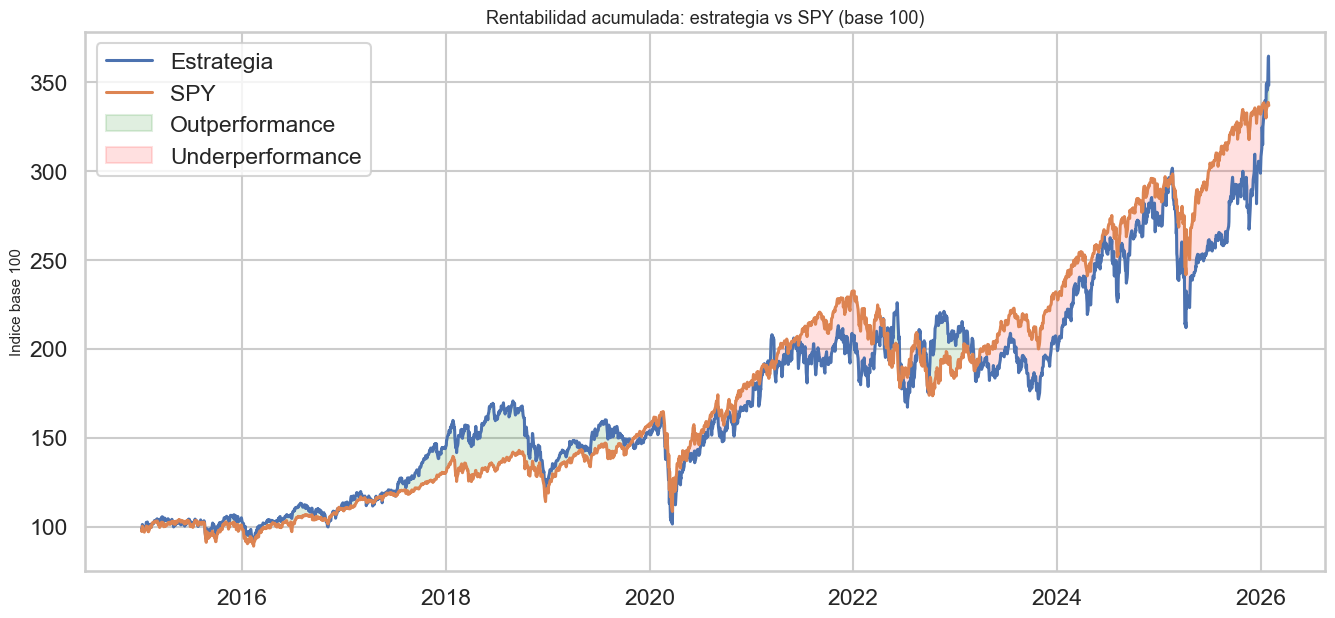

In [8]:
cum_index = (1 + returns_daily).cumprod() * 100
spread = cum_index["strategy"] - cum_index["spy"]

plt.figure(figsize=(16, 7))
plt.plot(cum_index.index, cum_index["strategy"], label="Estrategia", linewidth=2.2)
plt.plot(cum_index.index, cum_index["spy"], label="SPY", linewidth=2.2)

plt.fill_between(cum_index.index, cum_index["strategy"], cum_index["spy"], where=spread >= 0, color="green", alpha=0.12, label="Outperformance")
plt.fill_between(cum_index.index, cum_index["strategy"], cum_index["spy"], where=spread < 0, color="red", alpha=0.12, label="Underperformance")

plt.title("Rentabilidad acumulada: estrategia vs SPY (base 100)")
plt.ylabel("Indice base 100")
plt.legend(loc="upper left")
plt.show()

### Interpretacion curva acumulada

- que mide: evolucion acumulada estrategia vs SPY y periodos de dominancia relativa.
- resultado clave: el sombreado separa outperformance (verde) de underperformance (rojo).
- lectura: facilita identificar regimenes y episodios que explican el resultado final.
- limitacion: la curva no separa por si sola el efecto de friccion operativa o costes.

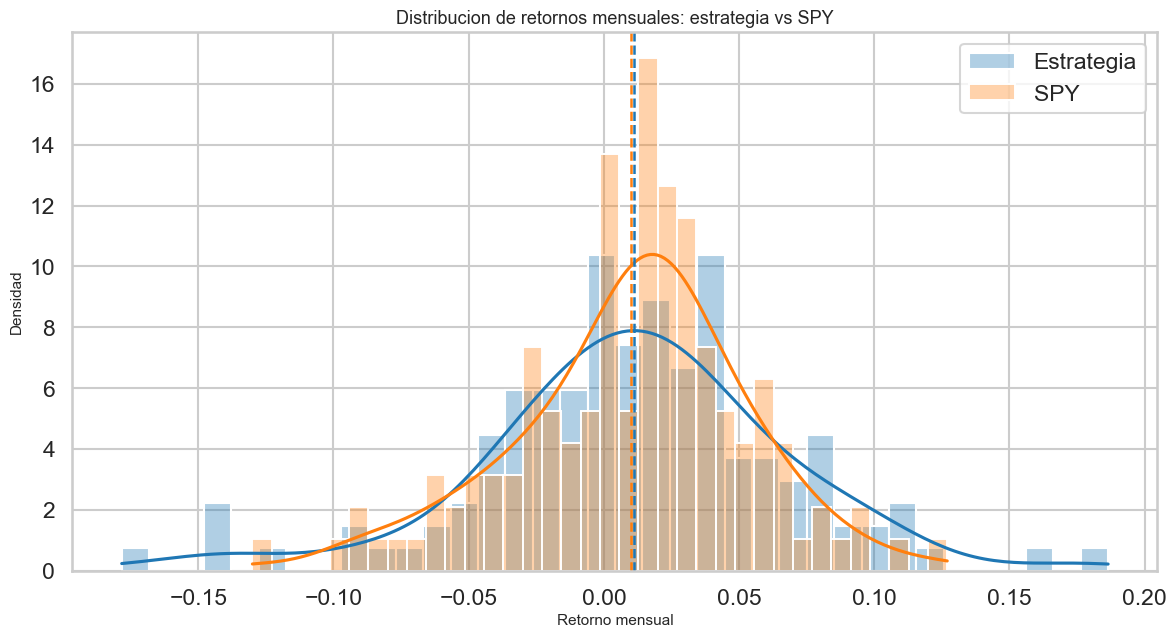

In [9]:
plt.figure(figsize=(14, 7))
sns.histplot(monthly_returns["strategy"], bins=36, stat="density", color="tab:blue", alpha=0.35, kde=True, label="Estrategia")
sns.histplot(monthly_returns["spy"], bins=36, stat="density", color="tab:orange", alpha=0.35, kde=True, label="SPY")
plt.axvline(monthly_returns["strategy"].mean(), color="tab:blue", linestyle="--", linewidth=1.8)
plt.axvline(monthly_returns["spy"].mean(), color="tab:orange", linestyle="--", linewidth=1.8)
plt.title("Distribucion de retornos mensuales: estrategia vs SPY")
plt.xlabel("Retorno mensual")
plt.ylabel("Densidad")
plt.legend()
plt.show()

### Interpretacion del histograma mensual

- que mide: distribucion mensual de retornos de estrategia y benchmark.
- resultado clave: bins + KDE exponen centro, dispersion, asimetria y colas.
- lectura: ayuda a comparar perfil de riesgo y comportamiento extremo entre ambos.
- limitacion: al agregar mensual se pierde informacion de secuencia diaria.

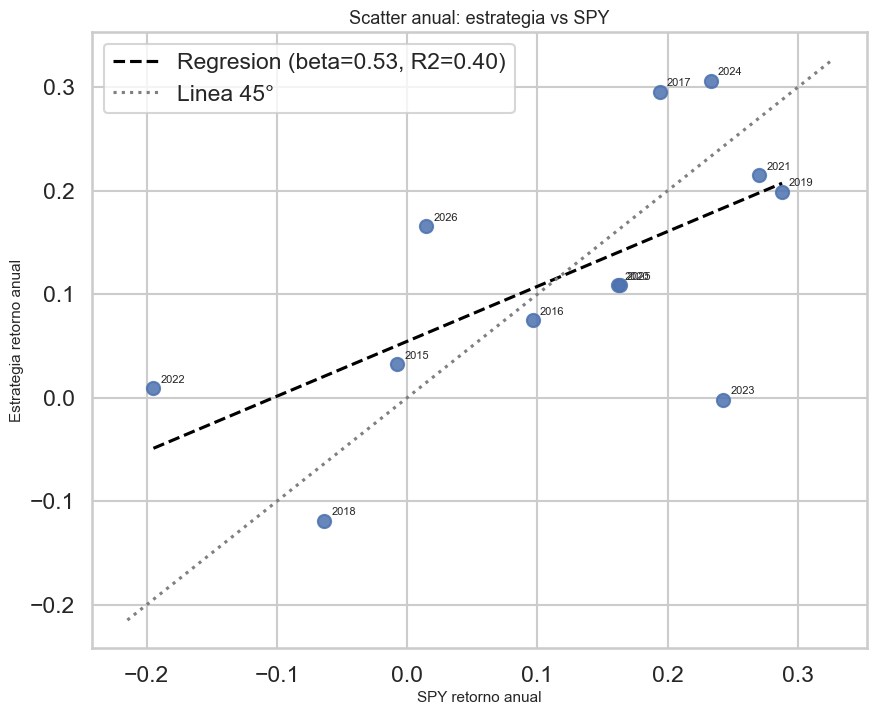

In [10]:
annual_scatter = annual_returns.dropna().copy()
annual_scatter["year"] = annual_scatter.index.year

x = annual_scatter["spy"].to_numpy()
y = annual_scatter["strategy"].to_numpy()
reg = stats.linregress(x, y)
r2 = reg.rvalue ** 2

plt.figure(figsize=(10, 8))
plt.scatter(x, y, s=90, alpha=0.85)
plt.plot(np.sort(x), reg.intercept + reg.slope * np.sort(x), color="black", linestyle="--", label=f"Regresion (beta={reg.slope:.2f}, R2={r2:.2f})")
lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
plt.plot(lims, lims, color="gray", linestyle=":", label="Linea 45°")

for _, row in annual_scatter.iterrows():
    plt.annotate(str(int(row["year"])), (row["spy"], row["strategy"]), textcoords="offset points", xytext=(5, 4), fontsize=8)

plt.title("Scatter anual: estrategia vs SPY")
plt.xlabel("SPY retorno anual")
plt.ylabel("Estrategia retorno anual")
plt.legend()
plt.show()

### Interpretacion scatter anual

- que mide: consistencia anual relativa frente al benchmark.
- resultado clave: pendiente y R2 resumen dependencia anual con SPY.
- lectura: puntos sobre la linea 45 grados indican mejor desempeno anual relativo.
- limitacion: el numero de anos es limitado y puede volver fragil la inferencia.

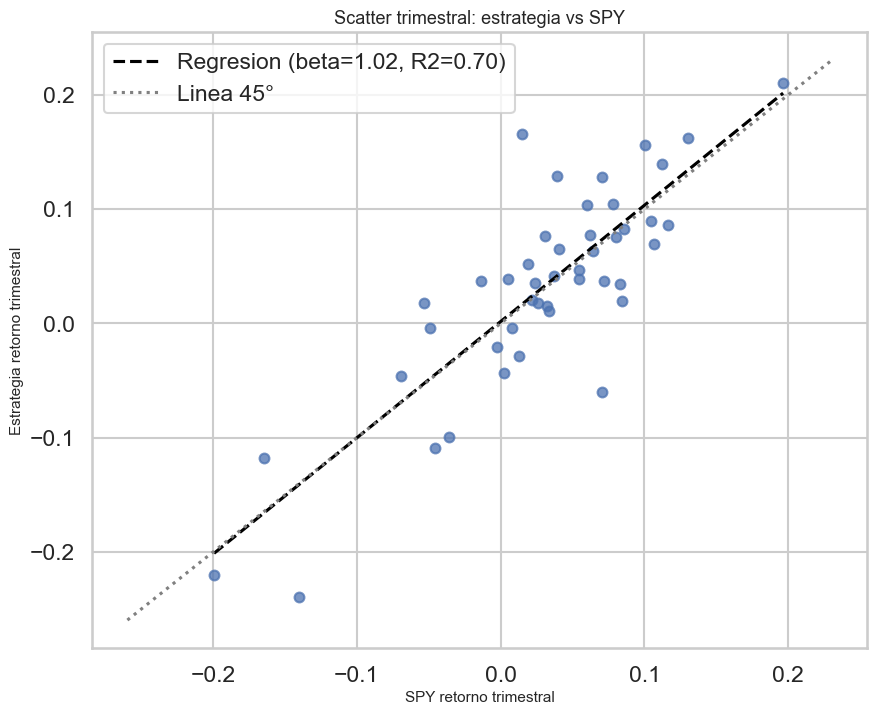

In [11]:
quarter_scatter = quarterly_returns.dropna().copy()
x = quarter_scatter["spy"].to_numpy()
y = quarter_scatter["strategy"].to_numpy()
reg_q = stats.linregress(x, y)
r2_q = reg_q.rvalue ** 2

plt.figure(figsize=(10, 8))
plt.scatter(x, y, s=50, alpha=0.75)
plt.plot(np.sort(x), reg_q.intercept + reg_q.slope * np.sort(x), color="black", linestyle="--", label=f"Regresion (beta={reg_q.slope:.2f}, R2={r2_q:.2f})")
lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
plt.plot(lims, lims, color="gray", linestyle=":", label="Linea 45°")
plt.title("Scatter trimestral: estrategia vs SPY")
plt.xlabel("SPY retorno trimestral")
plt.ylabel("Estrategia retorno trimestral")
plt.legend()
plt.show()

### Interpretacion scatter trimestral

- que mide: estabilidad intra-anual de la relacion estrategia vs benchmark.
- resultado clave: aumenta observaciones y mejora lectura de dispersion y beta tactica.
- lectura: detecta si la ventaja anual se sostiene en horizontes mas cortos.
- limitacion: los trimestres comparten shocks, no son totalmente independientes.

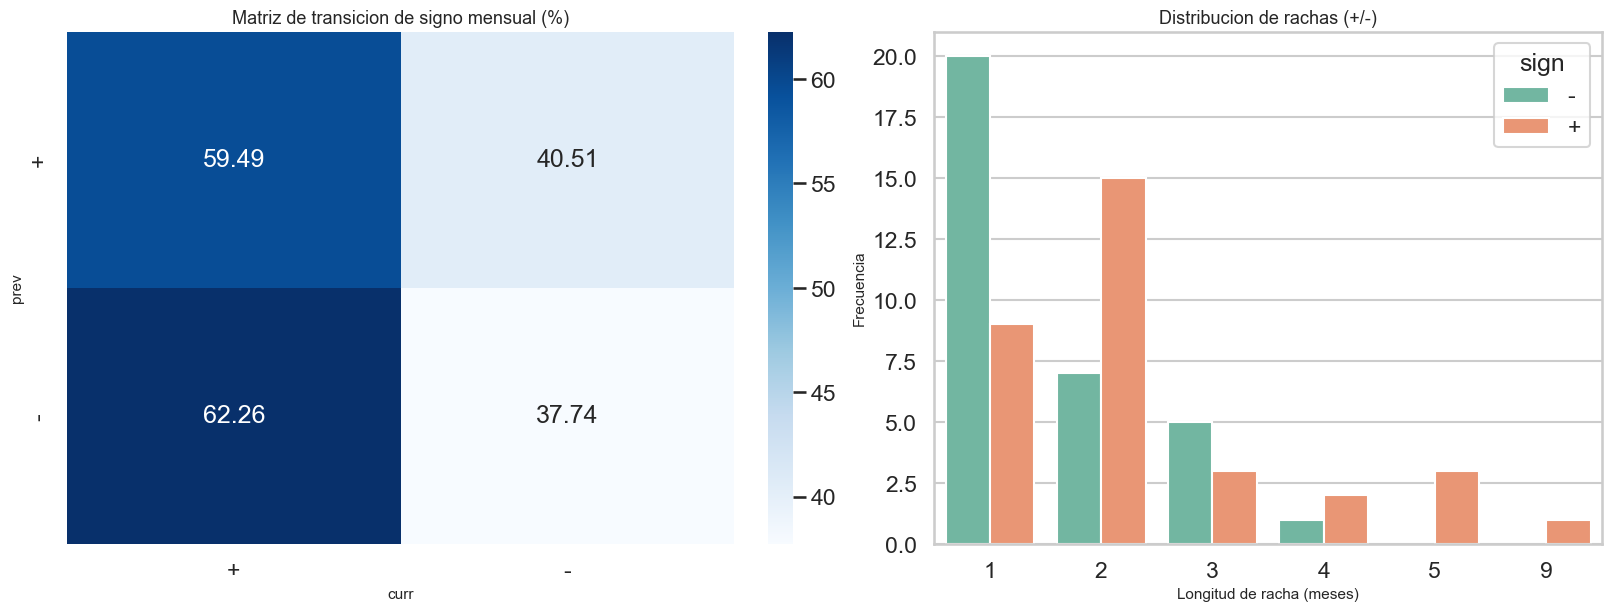

Probabilidades de transicion (%)


curr,+,-
prev,,
+,59.493671,40.506329
-,62.264151,37.735849


In [12]:
monthly_sign = np.where(monthly_returns["strategy"] >= 0, "+", "-")
trans_df = pd.DataFrame({"prev": pd.Series(monthly_sign).shift(1), "curr": monthly_sign}).dropna()
transition = pd.crosstab(trans_df["prev"], trans_df["curr"], normalize="index") * 100

sign_series = pd.Series(monthly_sign, index=monthly_returns.index)
groups = (sign_series != sign_series.shift(1)).cumsum()
streak_len = sign_series.groupby(groups).size()
streak_sign = sign_series.groupby(groups).first()
streak_df = pd.DataFrame({"sign": streak_sign.values, "length": streak_len.values})

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
sns.heatmap(transition, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de transicion de signo mensual (%)")

sns.countplot(data=streak_df, x="length", hue="sign", ax=axes[1], palette="Set2")
axes[1].set_title("Distribucion de rachas (+/-)")
axes[1].set_xlabel("Longitud de racha (meses)")
axes[1].set_ylabel("Frecuencia")
plt.show()

print("Probabilidades de transicion (%)")
display(transition)

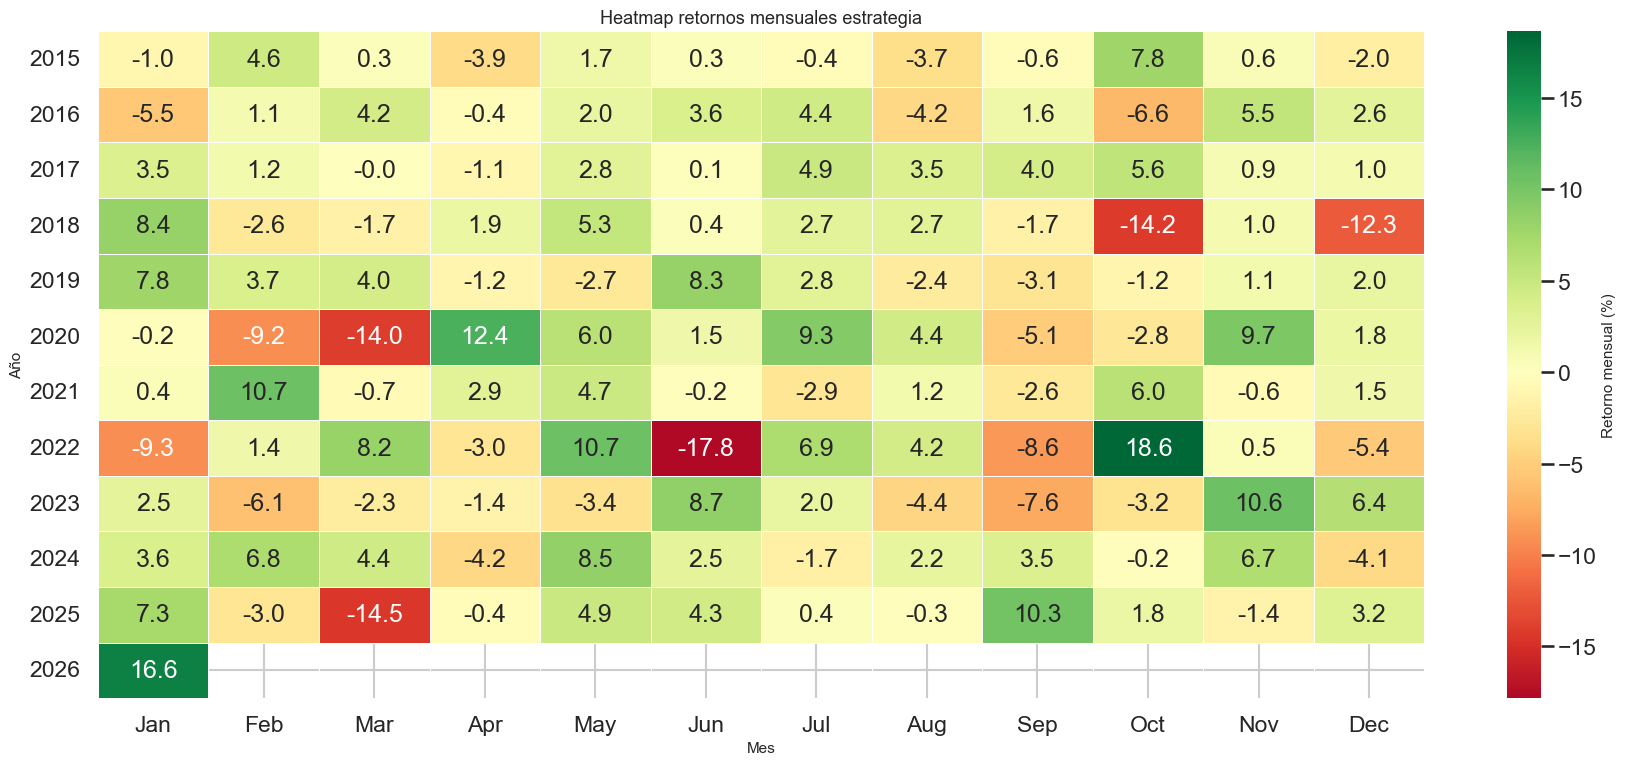

In [13]:
heat = monthly_returns["strategy"].copy() * 100
heat_df = pd.DataFrame(
    {
        "year": heat.index.year,
        "month": heat.index.month,
        "value": heat.values,
    }
)
heat_pivot = heat_df.pivot(index="year", columns="month", values="value")
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
heat_pivot = heat_pivot.reindex(columns=range(1, 13))

plt.figure(figsize=(18, 8))
sns.heatmap(heat_pivot, cmap="RdYlGn", center=0, annot=True, fmt=".1f", linewidths=0.4, cbar_kws={"label": "Retorno mensual (%)"})
plt.title("Heatmap retornos mensuales estrategia")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.xticks(np.arange(12) + 0.5, month_labels, rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretacion de recurrencia

- que mide: persistencia de meses positivos/negativos y longitud de rachas.
- resultado clave: matriz de transicion y heatmap ubican continuidad de regimen.
- lectura: permite detectar periodos de inercia positiva o deterioro prolongado.
- limitacion: el signo ignora magnitud del retorno y puede simplificar demasiado.

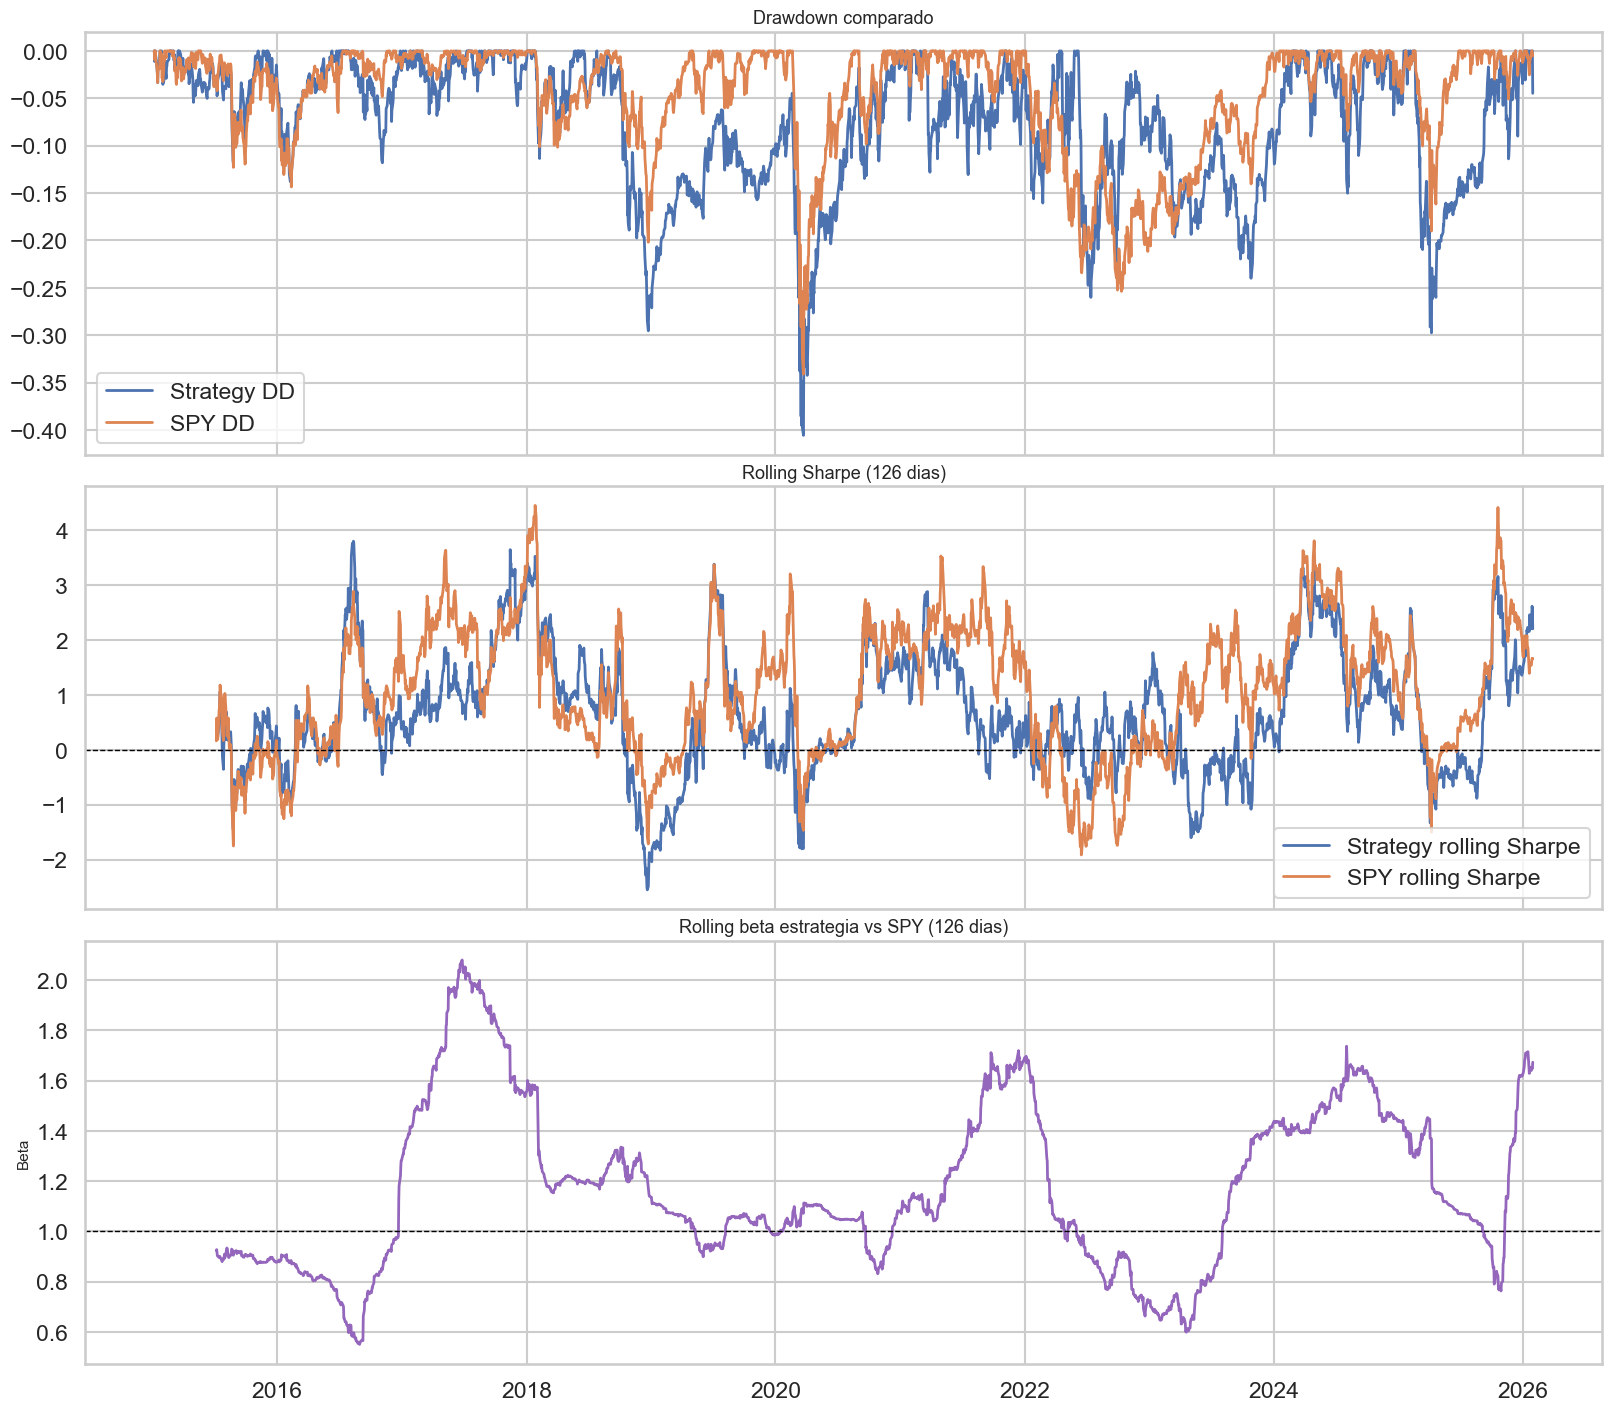

In [14]:
wealth_curve = (1 + returns_daily).cumprod()
drawdown = wealth_curve / wealth_curve.cummax() - 1

win = 126
roll_mean = returns_daily.rolling(win).mean()
roll_std = returns_daily.rolling(win).std(ddof=1)
rolling_sharpe = np.sqrt(TRADING_DAYS) * ((roll_mean - RF_DAILY) / roll_std)

rolling_beta = (
    returns_daily["strategy"].rolling(win).cov(returns_daily["spy"]) /
    returns_daily["spy"].rolling(win).var()
)

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True, constrained_layout=True)

axes[0].plot(drawdown.index, drawdown["strategy"], label="Strategy DD", linewidth=2)
axes[0].plot(drawdown.index, drawdown["spy"], label="SPY DD", linewidth=2)
axes[0].set_title("Drawdown comparado")
axes[0].legend()

axes[1].plot(rolling_sharpe.index, rolling_sharpe["strategy"], label="Strategy rolling Sharpe", linewidth=2)
axes[1].plot(rolling_sharpe.index, rolling_sharpe["spy"], label="SPY rolling Sharpe", linewidth=2)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Rolling Sharpe (126 dias)")
axes[1].legend()

axes[2].plot(rolling_beta.index, rolling_beta, color="tab:purple", linewidth=2)
axes[2].axhline(1, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Rolling beta estrategia vs SPY (126 dias)")
axes[2].set_ylabel("Beta")

plt.show()

### Interpretacion de riesgo dinamico

- que mide: profundidad de drawdown, estabilidad rolling Sharpe y beta variable.
- resultado clave: los tres paneles separan perdida, riesgo-ajustado y exposicion de mercado.
- lectura: muestra en que fases el rendimiento viene con mayor fragilidad.
- limitacion: cualquier metrica rolling depende de ventana y sufre ruido en extremos.

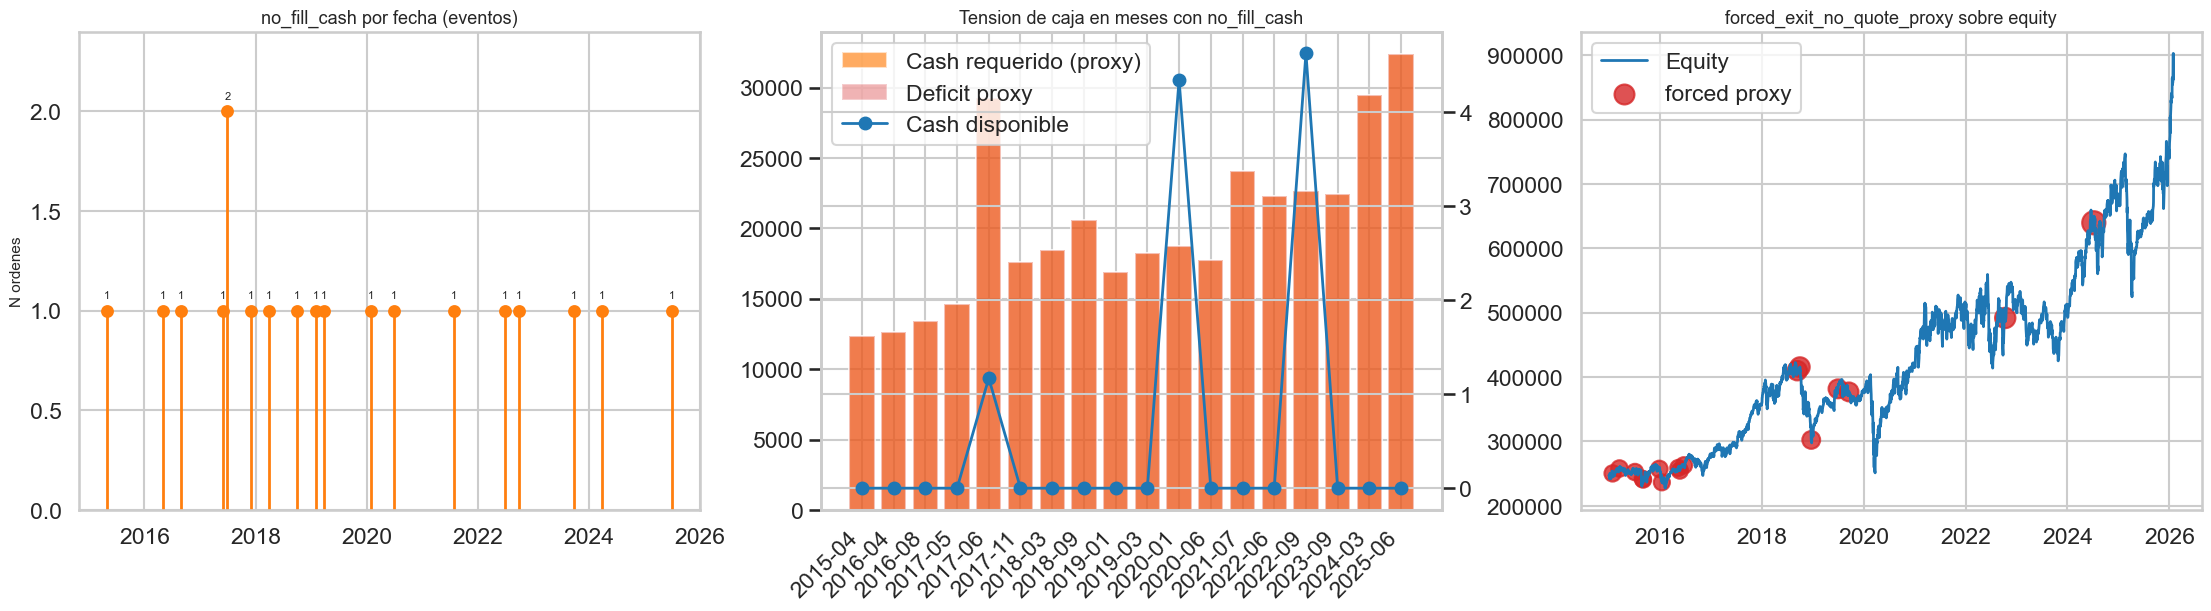

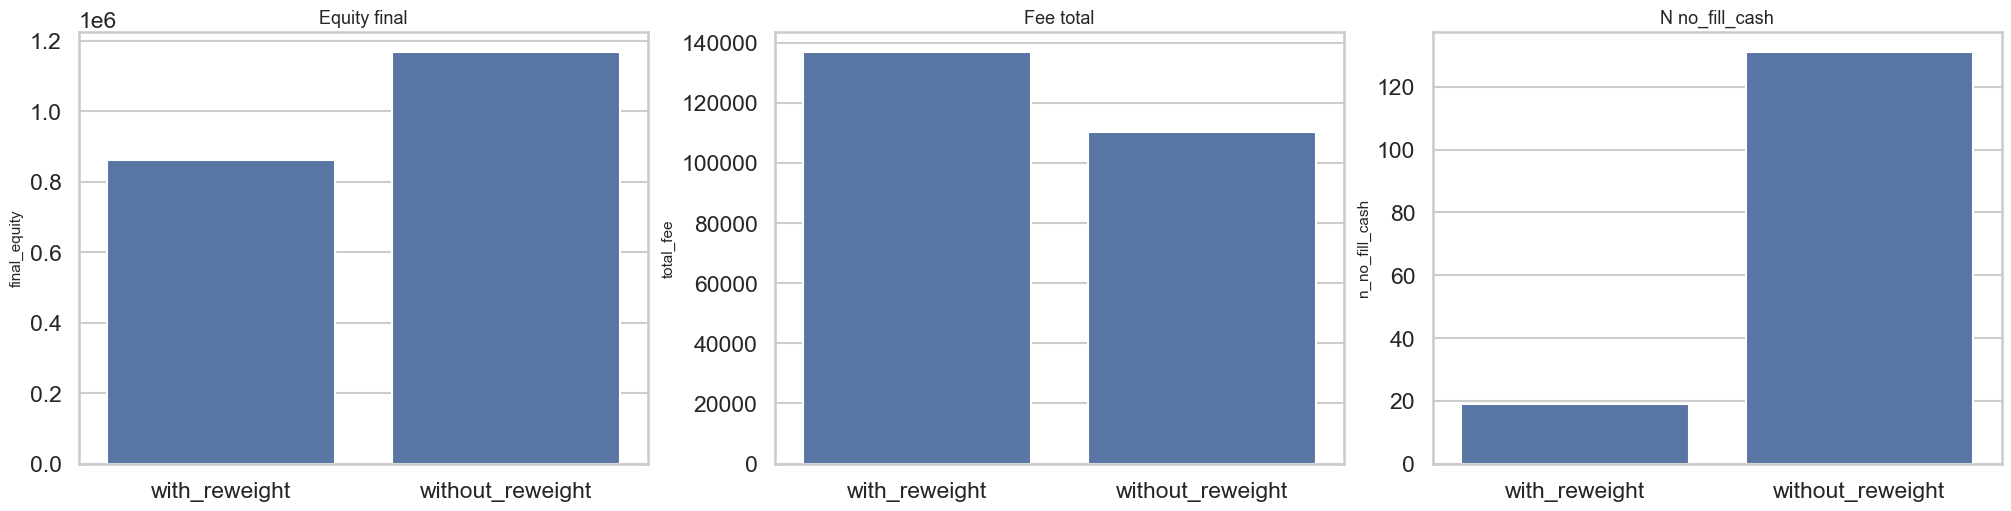

no_fill_cash: 19 ordenes en 18 fechas
forced_exit_no_quote_proxy: 17 casos, fee total=638.29


,policy_mode,final_equity,total_fee,n_no_fill_cash
0,with_reweight,8.625410e+05,136769.633799,19
1,without_reweight,1.167500e+06,110282.107299,131


In [15]:
no_fill_cash_df = orders.loc[
    orders["status"] == "no_fill_cash",
    ["date", "symbol", "reason", "price", "cash_after", "policy_mode"],
].copy().sort_values(["date", "symbol"])
no_fill_by_date = no_fill_cash_df.groupby("date").size().rename("count")

reb = rebalance_summary.copy().sort_values("date")
if "n_rebalance_entry_no_fill_cash" not in reb.columns:
    reb["n_rebalance_entry_no_fill_cash"] = 0
reb["required_cash_proxy"] = reb["equity"] * 0.05 * reb["n_rebalance_entry_no_fill_cash"]
reb["deficit_proxy"] = np.clip(reb["required_cash_proxy"] - reb["cash"], 0, None)
reb_tension = reb.loc[reb["n_rebalance_entry_no_fill_cash"] > 0].copy()

forced_proxy_df = orders.loc[
    (orders["reason"] == "forced_exit_no_quote_proxy") & (orders["status"] == "filled"),
    ["date", "symbol", "price", "fee", "proxy_price_date", "policy_mode"],
].copy().sort_values(["date", "symbol"])

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)

ax = axes[0]
if len(no_fill_by_date) > 0:
    ax.vlines(no_fill_by_date.index, 0, no_fill_by_date.values, color="tab:orange", linewidth=2)
    ax.scatter(no_fill_by_date.index, no_fill_by_date.values, color="tab:orange", s=60)
    for x, y in zip(no_fill_by_date.index, no_fill_by_date.values):
        ax.text(x, y + 0.05, f"{int(y)}", ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, max(2.2, (no_fill_by_date.values.max() if len(no_fill_by_date) else 1) + 0.4))
ax.set_title("no_fill_cash por fecha (eventos)")
ax.set_ylabel("N ordenes")

ax = axes[1]
if len(reb_tension) > 0:
    x = np.arange(len(reb_tension))
    labels = reb_tension["date"].dt.strftime("%Y-%m")
    ax.bar(x, reb_tension["required_cash_proxy"], color="tab:orange", alpha=0.65, label="Cash requerido (proxy)")
    ax.bar(x, reb_tension["deficit_proxy"], color="tab:red", alpha=0.35, label="Deficit proxy")
    ax2 = ax.twinx()
    ax2.plot(x, reb_tension["cash"], color="tab:blue", marker="o", linewidth=2, label="Cash disponible")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left")
ax.set_title("Tension de caja en meses con no_fill_cash")

ax = axes[2]
ax.plot(portfolio_daily["date"], portfolio_daily["equity"], color="tab:blue", linewidth=2, label="Equity")
if len(forced_proxy_df) > 0:
    forced_plot = forced_proxy_df.groupby("date", as_index=False)["fee"].sum()
    eq_map = portfolio_daily.set_index("date")["equity"]
    yvals = forced_plot["date"].map(eq_map)
    sizes = 40 + (forced_plot["fee"] / forced_plot["fee"].max() * 240)
    ax.scatter(forced_plot["date"], yvals, color="tab:red", s=sizes, alpha=0.8, label="forced proxy")
ax.set_title("forced_exit_no_quote_proxy sobre equity")
ax.legend(loc="upper left")

plt.show()

policy_tradeoff = n4_checks.loc[n4_checks["check"] == "policy_reweight_tradeoff_documented", "details"]
fail_if(len(policy_tradeoff) == 0, "No existe check policy_reweight_tradeoff_documented en n4_checks.csv")
tradeoff_text = policy_tradeoff.iloc[0]

m_fee = re.search(r"delta_fee=([-+]?\d*\.?\d+)", tradeoff_text)
m_eq = re.search(r"delta_final_equity=([-+]?\d*\.?\d+)", tradeoff_text)
m_nofill = re.search(r"delta_no_fill_cash=([-+]?\d+)", tradeoff_text)
fail_if(m_fee is None or m_eq is None or m_nofill is None, f"No se pudieron parsear deltas: {tradeoff_text}")

delta_fee = float(m_fee.group(1))
delta_eq = float(m_eq.group(1))
delta_nofill = int(m_nofill.group(1))

with_cost = cost_summary.iloc[0]
policy_kpis = pd.DataFrame(
    [
        {
            "policy_mode": "with_reweight",
            "final_equity": float(with_cost["final_equity"]),
            "total_fee": float(with_cost["total_fee"]),
            "n_no_fill_cash": int(float(with_cost["n_no_fill_cash"])),
        },
        {
            "policy_mode": "without_reweight",
            "final_equity": float(with_cost["final_equity"] - delta_eq),
            "total_fee": float(with_cost["total_fee"] - delta_fee),
            "n_no_fill_cash": int(float(with_cost["n_no_fill_cash"]) - delta_nofill),
        },
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
for ax, col, title in zip(
    axes,
    ["final_equity", "total_fee", "n_no_fill_cash"],
    ["Equity final", "Fee total", "N no_fill_cash"],
):
    sns.barplot(data=policy_kpis, x="policy_mode", y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")

plt.show()

print(f"no_fill_cash: {len(no_fill_cash_df)} ordenes en {no_fill_cash_df['date'].nunique()} fechas")
print(f"forced_exit_no_quote_proxy: {len(forced_proxy_df)} casos, fee total={forced_proxy_df['fee'].sum():.2f}")
display(policy_kpis)

Contexto de comisiones


,metric,value
0,Total fee (USD),136769.633799
1,Fee / Initial capital (%),54.707854
2,Fee / Final equity (%),15.856595
3,Buy fee (USD),68954.111194
4,Sell fee (USD),67815.522605
5,Forced exit proxy fee (USD),638.289359
6,Orders impacted by minimum fee,1623.000000
7,Extra fee due to minimum (USD),32353.978291


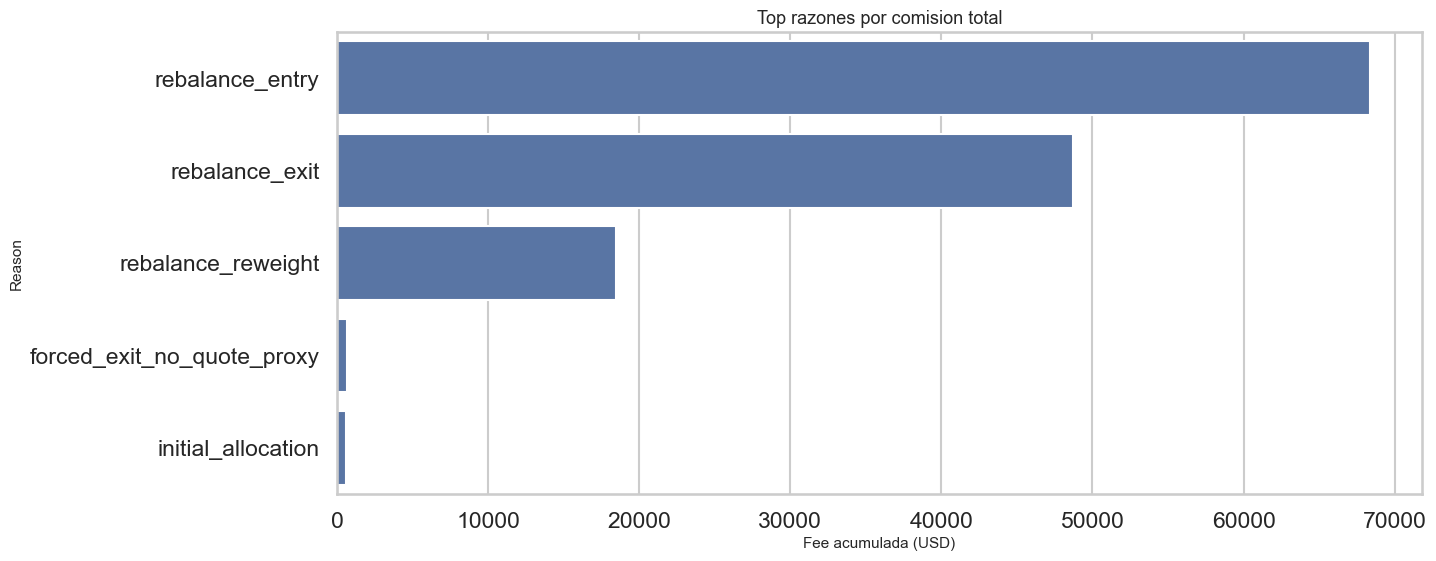

In [16]:
filled_orders = orders.loc[orders["status"] == "filled"].copy()
filled_orders = filled_orders.loc[filled_orders["notional"].abs() > 0].copy()

filled_orders["fee_prop"] = filled_orders["notional"].abs() * fee_rate
filled_orders["fee_model"] = np.maximum(filled_orders["fee_prop"], fee_min)
filled_orders["min_fee_hit"] = filled_orders["fee_prop"] < fee_min
filled_orders["extra_due_to_min"] = np.where(filled_orders["min_fee_hit"], fee_min - filled_orders["fee_prop"], 0.0)

n_min_hit = int(filled_orders["min_fee_hit"].sum())
extra_min_total = float(filled_orders["extra_due_to_min"].sum())

total_fee = float(cost_summary["total_fee"].iloc[0])
initial_capital = float(cost_summary["initial_capital"].iloc[0])
final_equity = float(cost_summary["final_equity"].iloc[0])

commission_context = pd.DataFrame(
    [
        {"metric": "Total fee (USD)", "value": total_fee},
        {"metric": "Fee / Initial capital (%)", "value": 100 * total_fee / initial_capital},
        {"metric": "Fee / Final equity (%)", "value": 100 * total_fee / final_equity},
        {"metric": "Buy fee (USD)", "value": float(cost_summary["buy_fee"].iloc[0])},
        {"metric": "Sell fee (USD)", "value": float(cost_summary["sell_fee"].iloc[0])},
        {"metric": "Forced exit proxy fee (USD)", "value": float(cost_summary["forced_exit_proxy_fee"].iloc[0])},
        {"metric": "Orders impacted by minimum fee", "value": n_min_hit},
        {"metric": "Extra fee due to minimum (USD)", "value": extra_min_total},
    ]
)

print("Contexto de comisiones")
display(commission_context)

fee_reason = (
    filled_orders.groupby("reason", as_index=False)["fee"]
    .sum()
    .sort_values("fee", ascending=False)
    .head(10)
)

plt.figure(figsize=(14, 6))
sns.barplot(data=fee_reason, x="fee", y="reason", orient="h")
plt.title("Top razones por comision total")
plt.xlabel("Fee acumulada (USD)")
plt.ylabel("Reason")
plt.show()

### Interpretacion operativa y metodologia Monte Carlo principal

- que mide: friccion operativa real (no_fill, forced proxy, comisiones) y su impacto neto.
- resultado clave: se cuantifica tradeoff with/without reweight y sobrecoste del minimo de 23 USD.
- lectura: el alpha bruto solo es defendible tras descontar ejecucion y costes reales.
- limitacion: el contraste with/without usa agregados del check, no replay tick a tick.

## Monte Carlo principal (directo, no parametrico)

Parametros fijos:
- `N_MONKEYS = 25_000_000`
- `MONKEY_SEED = 42`
- `MONKEY_PORTFOLIO_SIZE = 20`
- `MONKEY_MONTHLY_COST = 0.0046`

Metodologia:
- retorno forward mensual real por activo elegible,
- muestreo sin reemplazo de 20 activos por mes y por mono,
- retorno de cartera media mensual menos coste fijo,
- acumulacion de riqueza final por batches y control de tiempo (<24h).

Mes 001/132 | fecha=2015-01-30 | elapsed=0.48 min
Mes 012/132 | fecha=2015-12-31 | elapsed=5.84 min
Mes 024/132 | fecha=2016-12-30 | elapsed=11.72 min
Mes 036/132 | fecha=2017-12-29 | elapsed=17.61 min
Mes 048/132 | fecha=2018-12-31 | elapsed=23.62 min
Mes 060/132 | fecha=2019-12-31 | elapsed=29.19 min
Mes 072/132 | fecha=2020-12-31 | elapsed=34.92 min
Mes 084/132 | fecha=2021-12-31 | elapsed=40.37 min
Mes 096/132 | fecha=2022-12-30 | elapsed=45.84 min
Mes 108/132 | fecha=2023-12-29 | elapsed=51.31 min
Mes 120/132 | fecha=2024-12-31 | elapsed=56.77 min
Mes 132/132 | fecha=2025-12-31 | elapsed=62.25 min


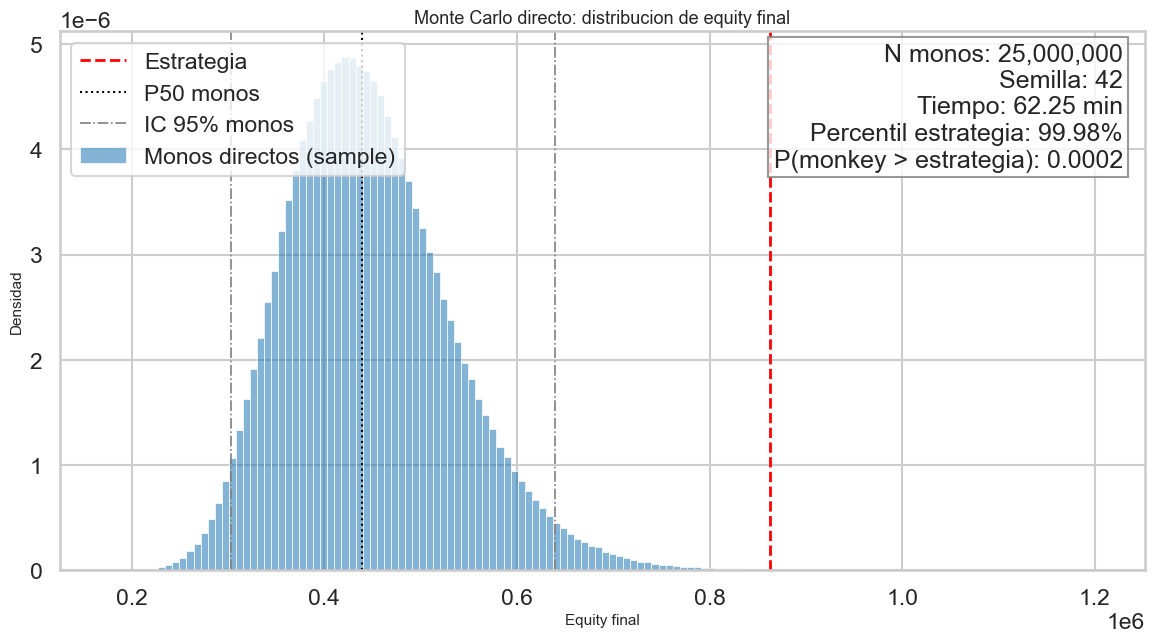

Monte Carlo directo completado
Monos simulados: 25,000,000
Meses simulados por mono: 132
Tiempo total: 3735.07 s (62.25 min)
Requisito enunciado (<24h): PASS
Percentil estrategia: 99.98%
P(monkey > estrategia): 0.0002
Monos P5/P50/P95: 321,917.06 / 439,172.30 / 601,367.62
IC 95% monos: [303,403.84, 639,080.44]


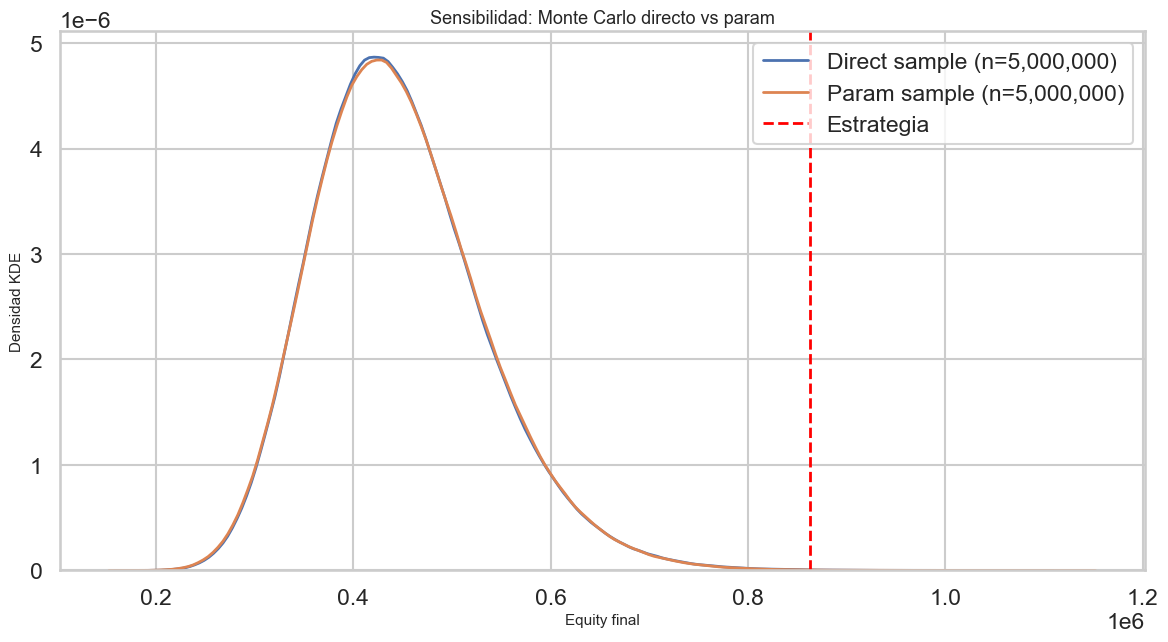

Sensibilidad param calculada en 10.85s con n=5,000,000


,model,mean,p05,p50,p95,delta_vs_direct
0,direct,447448.96875,321928.34375,439154.125,601321.875,0.00000
1,param,447501.56250,321002.96875,439491.750,601134.375,52.59375


In [17]:
strategy_final_equity = float(cost_summary["final_equity"].iloc[0])
initial_capital = float(cost_summary["initial_capital"].iloc[0])

signals_mc = signals_input[["rebalance_date", "symbol", "eligible_for_signals", "close_rebalance"]].copy()
signals_mc["rebalance_date"] = pd.to_datetime(signals_mc["rebalance_date"])
signals_mc = signals_mc.sort_values(["symbol", "rebalance_date"]).reset_index(drop=True)

signals_mc["close_next"] = signals_mc.groupby("symbol", observed=True)["close_rebalance"].shift(-1)
signals_mc["fwd_monthly_return"] = signals_mc["close_next"] / signals_mc["close_rebalance"] - 1

signal_months = rebalance_summary["date"].drop_duplicates().sort_values()
mc_universe = signals_mc.loc[
    (signals_mc["rebalance_date"].isin(signal_months))
    & (signals_mc["eligible_for_signals"] == True)
    & np.isfinite(signals_mc["fwd_monthly_return"])
    & (signals_mc["fwd_monthly_return"] > -0.999),
    ["rebalance_date", "symbol", "fwd_monthly_return"],
].copy()

month_groups = []
for dt, grp in mc_universe.groupby("rebalance_date", observed=True):
    arr = grp["fwd_monthly_return"].to_numpy(dtype=np.float32)
    if len(arr) >= MONKEY_PORTFOLIO_SIZE:
        month_groups.append((pd.Timestamp(dt), arr))

fail_if(len(month_groups) == 0, "No hay meses validos para Monte Carlo directo")

rng = np.random.default_rng(MONKEY_SEED)
log_growth = np.zeros(N_MONKEYS, dtype=np.float32)

t0 = time.perf_counter()

for m_idx, (month_dt, month_ret_arr) in enumerate(month_groups, start=1):
    n_assets = month_ret_arr.size
    start = 0
    while start < N_MONKEYS:
        batch = min(MONKEY_BATCH_SIZE, N_MONKEYS - start)
        idx = sample_without_replacement_rows(
            rng=rng,
            n_rows=batch,
            n_assets=n_assets,
            k=MONKEY_PORTFOLIO_SIZE,
        )
        sampled_ret = month_ret_arr[idx].mean(axis=1, dtype=np.float32) - MONKEY_MONTHLY_COST
        sampled_ret = np.clip(sampled_ret, -0.95, None)
        log_growth[start:start + batch] += np.log1p(sampled_ret).astype(np.float32)
        start += batch

    if m_idx == 1 or m_idx % 12 == 0 or m_idx == len(month_groups):
        elapsed = time.perf_counter() - t0
        print(f"Mes {m_idx:03d}/{len(month_groups)} | fecha={month_dt.date()} | elapsed={elapsed/60:.2f} min")

direct_elapsed = time.perf_counter() - t0
monkey_direct_wealth = (initial_capital * np.exp(log_growth.astype(np.float64))).astype(np.float32)

p_strategy_direct = float((monkey_direct_wealth <= strategy_final_equity).mean() * 100)
p_monkey_beats_direct = float((monkey_direct_wealth > strategy_final_equity).mean())
p05_d, p50_d, p95_d = np.percentile(monkey_direct_wealth, [5, 50, 95])
ci_low_d, ci_high_d = np.percentile(monkey_direct_wealth, [2.5, 97.5])

plot_n = min(MONKEY_PLOT_SAMPLE_N, len(monkey_direct_wealth))
plot_idx = rng.integers(0, len(monkey_direct_wealth), size=plot_n)
plot_sample_direct = monkey_direct_wealth[plot_idx]

plt.figure(figsize=(14, 7))
sns.histplot(plot_sample_direct, bins=140, stat="density", color="tab:blue", alpha=0.55, label="Monos directos (sample)")
plt.axvline(strategy_final_equity, color="red", linestyle="--", linewidth=2.0, label="Estrategia")
plt.axvline(p50_d, color="black", linestyle=":", linewidth=1.5, label="P50 monos")
plt.axvline(ci_low_d, color="gray", linestyle="-.", linewidth=1.2, label="IC 95% monos")
plt.axvline(ci_high_d, color="gray", linestyle="-.", linewidth=1.2)

textbox = (
    f"N monos: {N_MONKEYS:,}\n"
    f"Semilla: {MONKEY_SEED}\n"
    f"Tiempo: {direct_elapsed/60:.2f} min\n"
    f"Percentil estrategia: {p_strategy_direct:.2f}%\n"
    f"P(monkey > estrategia): {p_monkey_beats_direct:.4f}"
)
plt.text(0.98, 0.98, textbox, transform=plt.gca().transAxes, ha="right", va="top", bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"))

plt.title("Monte Carlo directo: distribucion de equity final")
plt.xlabel("Equity final")
plt.ylabel("Densidad")
plt.legend(loc="upper left")
plt.show()

print("Monte Carlo directo completado")
print(f"Monos simulados: {N_MONKEYS:,}")
print(f"Meses simulados por mono: {len(month_groups)}")
print(f"Tiempo total: {direct_elapsed:.2f} s ({direct_elapsed/60:.2f} min)")
print(f"Requisito enunciado (<24h): {'PASS' if direct_elapsed < 24 * 3600 else 'FAIL'}")
print(f"Percentil estrategia: {p_strategy_direct:.2f}%")
print(f"P(monkey > estrategia): {p_monkey_beats_direct:.4f}")
print(f"Monos P5/P50/P95: {p05_d:,.2f} / {p50_d:,.2f} / {p95_d:,.2f}")
print(f"IC 95% monos: [{ci_low_d:,.2f}, {ci_high_d:,.2f}]")

param_n = min(N_MONKEYS_PARAM_SENS, N_MONKEYS)
rng_param = np.random.default_rng(MONKEY_SEED)

mu_list = []
std_list = []
for _, arr in month_groups:
    mu = float(np.mean(arr) - MONKEY_MONTHLY_COST)
    sigma = float(np.std(arr, ddof=1))
    n_assets = len(arr)
    fpc = np.sqrt(max((n_assets - MONKEY_PORTFOLIO_SIZE) / (n_assets - 1), 0.0)) if n_assets > 1 else 0.0
    std_mean = sigma / np.sqrt(MONKEY_PORTFOLIO_SIZE) * fpc
    mu_list.append(mu)
    std_list.append(std_mean)

mu_arr = np.array(mu_list, dtype=np.float32)
std_arr = np.array(std_list, dtype=np.float32)

log_growth_param = np.zeros(param_n, dtype=np.float32)
t0 = time.perf_counter()
for m in range(len(mu_arr)):
    draws = rng_param.normal(loc=float(mu_arr[m]), scale=float(std_arr[m]), size=param_n).astype(np.float32)
    draws = np.clip(draws, -0.95, None)
    log_growth_param += np.log1p(draws).astype(np.float32)
param_elapsed = time.perf_counter() - t0

monkey_param_wealth = (initial_capital * np.exp(log_growth_param.astype(np.float64))).astype(np.float32)

if len(monkey_direct_wealth) > param_n:
    idx = rng_param.integers(0, len(monkey_direct_wealth), size=param_n)
    direct_sample = monkey_direct_wealth[idx]
else:
    direct_sample = monkey_direct_wealth.astype(np.float32)

compare_table = pd.DataFrame(
    [
        {
            "model": "direct",
            "mean": float(np.mean(direct_sample)),
            "p05": float(np.percentile(direct_sample, 5)),
            "p50": float(np.percentile(direct_sample, 50)),
            "p95": float(np.percentile(direct_sample, 95)),
        },
        {
            "model": "param",
            "mean": float(np.mean(monkey_param_wealth)),
            "p05": float(np.percentile(monkey_param_wealth, 5)),
            "p50": float(np.percentile(monkey_param_wealth, 50)),
            "p95": float(np.percentile(monkey_param_wealth, 95)),
        },
    ]
)

direct_mean = compare_table.loc[compare_table["model"] == "direct", "mean"].iloc[0]
compare_table["delta_vs_direct"] = compare_table["mean"] - direct_mean

plt.figure(figsize=(14, 7))
sns.kdeplot(direct_sample, label=f"Direct sample (n={len(direct_sample):,})", linewidth=2)
sns.kdeplot(monkey_param_wealth, label=f"Param sample (n={len(monkey_param_wealth):,})", linewidth=2)
plt.axvline(strategy_final_equity, color="red", linestyle="--", linewidth=2, label="Estrategia")
plt.title("Sensibilidad: Monte Carlo directo vs param")
plt.xlabel("Equity final")
plt.ylabel("Densidad KDE")
plt.legend()
plt.show()

print(f"Sensibilidad param calculada en {param_elapsed:.2f}s con n={param_n:,}")
display(compare_table)

## Cierre analitico final

### Interpretacion Monte Carlo y sensibilidad

- que mide: robustez de la estrategia frente a agentes aleatorios bajo reglas operativas del enunciado.
- resultado clave: usar percentil estrategia, `P(monkey > estrategia)`, `P5/P50/P95`, IC95 y `PASS <24h`.
- lectura: el Monte Carlo directo manda; el parametrico es solo contraste de consistencia.
- limitacion: el modelo parametrico suaviza colas y no replica toda la estructura cross-sectional.

## Analisis critico final (evidencia cuantitativa)

### 1) Sesgo de supervivencia
Evidencia: el universo y elegibilidad se construyen con trazabilidad PIT en `n2_signals_input`.
Riesgo residual: el historico disponible puede no capturar todos los sesgos de cobertura externa.

### 2) Look-ahead
Evidencia: senales con lags t-1/t-7/t-13 y ejecucion separada en artefactos N2/N3/N4.
Riesgo residual: cualquier error de timestamp upstream comprometeria la pureza temporal.

### 3) Overfitting
Evidencia: reglas fijas de seleccion/pesos/costes sin tuning ex post en N5.
Riesgo residual: la estrategia sigue calibrada sobre un unico mercado/periodo historico.

### 4) Realismo de rebalanceo
Evidencia: protocolo open/close, `no_fill_cash`, `forced_exit_no_quote_proxy` y comparativa de politica.
Riesgo residual: faltan impactos de latencia/slippage intradia mas finos.

### 5) Impacto de comisiones y minimo
Evidencia: fee total en USD, porcentajes sobre capital/equity final, desglose buy/sell/forced y extra por minimo.
Riesgo residual: una estructura de costes distinta puede alterar la jerarquia de resultados.

## Conclusion ejecutiva

N5 integra retorno, riesgo, operativa y robustez en un flujo auditable.
La evidencia defendible combina metricas obligatorias, visualizacion clara y costes netos.
El resultado economico no debe leerse sin friccion operativa.
La robustez principal viene del Monte Carlo directo de 25M monos.
El contraste parametrico solo valida orden de magnitud.
Las limitaciones metodologicas quedan explicitadas para evitar sobreinterpretacion.